**🌐 언어:** [← English](./why_causal_inference_en.ipynb) | **한국어**

# 우리가 왜 인과추론에 관심을 가져야 할까요?


인과추론은 반사실(Counterfactuals)이라 부르는 "만약에" 질문에 답하는 것을 요구합니다.

예를 들어 교육 정책을 고민한다고 해볼게요. 예산이 한정되어 있을 때, 모든 학생에게 태블릿을 지급해야 할까요? 아니면 도서관을 지어야 할까요?

이 질문의 핵심에는 인과적 질문이 있습니다.

이러한 인과적 질문은 일상 곳곳에 스며들어 있어요. 교육 수준이 높아지면 정말 소득이 늘어날까요? 담배 가격을 올리면 흡연율이 줄어들까요? 새로운 광고 캠페인이 실제로 매출을 올려줄까요?

이런 질문들은 어떤 분야에 있든 한 번쯤은 마주치게 됩니다.

그런데 막상 답하려면 생각보다 훨씬 어렵습니다. "상관관계는 인과관계가 아니다"라는 말은 익숙하지만, 왜 그런지를 제대로 설명하기는 쉽지 않아요.

## 1) 반사실과 잠재적 결과: 인과효과의 출발점

직관적으로, 연관관계가 왜 인과관계가 아닌지는 어렵지 않게 이해할 수 있습니다.

태블릿이 있는 학교의 성적이 높다고 해볼게요. 하지만 태블릿을 도입한 학교가 애초에 재정이 더 좋고, 보충수업이나 교사 확보가 더 잘 되어 있었다면, 그 학생들은 태블릿이 없었어도 평균보다 잘했을 거예요.

따라서 "태블릿이 학업 성취를 높인다"고 결론 내릴 수는 없습니다. 우리가 말할 수 있는 건, 태블릿과 높은 학업 성과 사이에 연관관계가 있다는 것뿐입니다.

In [9]:
import pandas as pd
import numpy as np
from scipy.special import expit
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style

style.use("fivethirtyeight")

np.random.seed(123)
n = 100
tuition = np.random.normal(1000, 300, n).round()
tablet = np.random.binomial(1, expit((tuition - tuition.mean()) / tuition.std())).astype(bool)
enem_score = np.random.normal(200 - 50 * tablet + 0.7 * tuition, 200)
enem_score = (enem_score - enem_score.min()) / enem_score.max()
enem_score *= 1000

data = pd.DataFrame(dict(enem_score=enem_score, Tuition=tuition, Tablet=tablet))

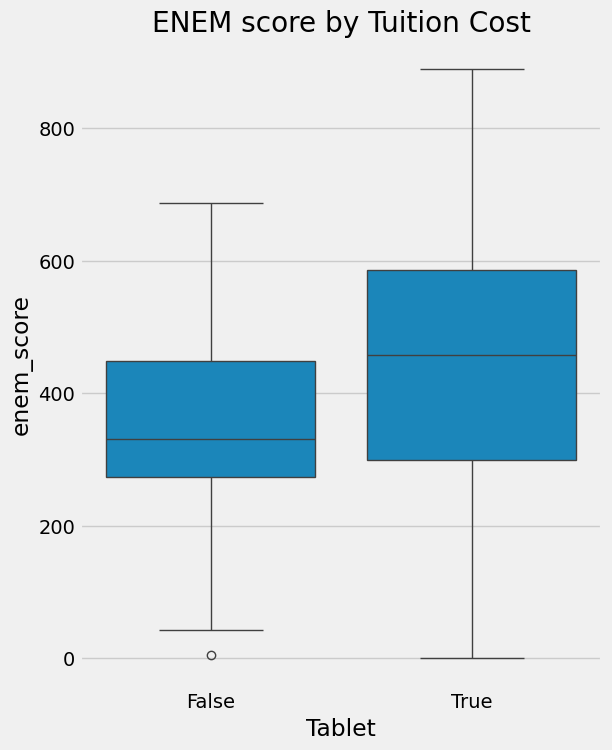

In [10]:
plt.figure(figsize=(6,8))
sns.boxplot(y="enem_score", x="Tablet", data = data).set_title('ENEM score by Tuition Cost')
plt.show()

단순한 직관을 넘어, 이제 본격적으로 표기법을 정의해 보겠습니다. 앞으로 인과관계를 이야기할 때 공통 언어로 사용할 것이니, 익숙해지는 것이 중요합니다.

$T_i$는 실험대상 $i$의 처치 여부를 나타냅니다.

$$
T_i=\begin{cases}
1 & \text{: 실험대상 } i \text{가 처치를 받은 경우}\\
0 & \text{: 실험대상 } i \text{가 처치를 받지 않은 경우}
\end{cases}
$$

여기서 처치(Treatment)란 효과를 알고자 하는 개입(intervention)을 의미합니다. 앞선 예시라면 학생들에게 태블릿을 지급하는 것이 처치에 해당합니다.

다음으로, 실험대상 $i$에 대해 관찰된 결과 변수(Outcome variable)를 $Y_i$로 정의합니다. "처치가 이 결과에 영향을 미치는가?"가 인과추론이 답하려는 질문입니다. 위 예시에서는 학업 성취도가 결과 변수입니다.

그런데 여기서 근본적인 문제가 생깁니다.

같은 학생이 태블릿을 받은 세계와 받지 않은 세계를 동시에 관찰할 수 없습니다. 둘 중 하나의 현실만 존재하기 때문입니다. 이것이 인과추론을 어렵게 만드는 핵심 이유입니다.
이 문제를 정교하게 다루기 위해 잠재적 결과(Potential Outcomes) 개념을 사용합니다.

- $Y_{0i}$ : 실험대상 $i$가 처치를 받지 않았을 때의 잠재적 결과
- $Y_{1i}$ : 실험대상 $i$가 처치를 받았을 때의 잠재적 결과

두 값 모두 "있을 수 있는 결과"이지만, 실제로 관찰할 수 있는 것은 둘 중 하나뿐입니다. 예를 들어 학생 $i = 1$이 태블릿을 받았다면 $Y_{11}$은 관찰할 수 있지만, $Y_{01}$은 관찰할 수 없습니다.

이처럼 실제로 일어난 결과를 사실(Factual), 일어나지 않은 쪽의 결과를 반사실(Counterfactual) 이라 부릅니다.

이 개념을 바탕으로 개별 처치 효과(ITE, Individual Treatment Effect)를 정의할 수 있습니다.

$$ITE_i = Y_{1i} - Y_{0i}$$

한 사람에게 처치가 있을 때와 없을 때의 결과 차이, 즉 "이 사람에게 처치가 얼마나 효과가 있었는가?"를 나타냅니다. 직관적으로 명확하지만, 반사실을 관찰할 수 없으므로 ITE는 직접 계산할 수 없습니다.

그래서 현실적인 대안으로 평균 처치 효과(ATE, Average Treatment Effect)를 활용합니다.

$$ATE = E[Y_1 - Y_0]$$

$E[\cdots]$는 기댓값, 즉 평균을 나타냅니다.  ATE는 "전체 집단에서 처치의 평균적인 효과는 얼마인가?"를 묻습니다.

한편 전체 집단이 아닌, 실제로 처치를 받은 사람들에게 처치가 얼마나 효과적이었는지를 보는 지표도 있습니다. 처치받은 그룹의 평균 처치 효과(ATT, Average Treatment Effect on the Treated)입니다.

$$ATT = E[Y_1 - Y_0 \mid T=1]$$

이해를 돕기 위해, 멀티버스를 넘나들며 반사실을 볼 수 있다고 가정해 볼게요. 

이 능력으로 4개 학교의 데이터를 수집한다면, 각 학생의 태블릿 지급 여부와 연간 학업 시험 점수를 모두 알 수 있습니다. 
여기서 태블릿 지급이 처치($T=1$)이고, $Y$는 시험 점수로 측정한 학업 성취도입니다.
이 경우 각 개체의 $Y_1$, $Y_0$를 직접 비교할 수 있으므로, $ATE$와 $ATT$를 계산하는 것도 어렵지 않습니다.

In [11]:
pd.DataFrame(dict(
    i= [1,2,3,4],
    y0=[500,600,800,700],
    y1=[450,600,600,750],
    t= [0,0,1,1],
    y= [500,600,600,750],
    ite=[-50,0,-200,50],
))

,i,y0,y1,t,y,ite
0,1,500,450,0,500,-50
1,2,600,600,0,600,0
2,3,800,600,1,600,-200
3,4,700,750,1,750,50


여기서 $ATE$는 마지막 열에 대한 평균 즉, 개별 처치 효과(ITE)에 대한 평균입니다.

$ATE=(-50 + 0 - 200 + 50)/4 = -50$

태블릿 지급이 학생들의 학업 성취도를 평균적으로 50점 낮췄다는 것을 의미합니다. 

$ATT$는 처치받은 학교($T=1$)만 골라 $ITE$를 평균한 값입니다.

$ATT=(- 200 + 50)/2 = -75$

태블릿을 받은 학교들에 한정하면, 태블릿이 학업 성취도를 평균 75점 낮춘 셈입니다.

그런데 이 계산이 가능했던 건 멀티버스 넘나들 수 있는 능력 덕분에 반사실 데이터까지 모두 갖고 있었기 때문입니다. 현실은 이렇습니다.

In [4]:
pd.DataFrame(dict(
    i= [1,2,3,4],
    y0=[500,600,np.nan,np.nan],
    y1=[np.nan,np.nan,600,750],
    t= [0,0,1,1],
    y= [500,600,600,750],
    te=[np.nan,np.nan,np.nan,np.nan],
))

,i,y0,y1,t,y,te
0,1,500.0,NaN,0,500,NaN
1,2,600.0,NaN,0,600,NaN
2,3,NaN,600.0,1,600,NaN
3,4,NaN,750.0,1,750,NaN


처치를 받은 사람의 $Y_0$, 처치를 받지 않은 사람의 $Y_1$은 끝내 관찰되지 않습니다. ITE를 계산할 수 없으니, 당연히 ATE와 ATT도 직접 구할 수 없습니다.

그렇다면 이런 생각이 드실 수 있습니다.

> "그냥 처치 집단과 비교 집단의 평균을 빼면 안 되나?"

$ATE=(600+750)/2 - (500 + 600)/2 = 125$

안 됩니다. 아까 구한 $ATE = -50$과 비교해보세요. 부호조차 반대입니다. 단순 평균 비교는 처치 효과가 긍정적이라고 말하지만, 실제로는 부정적이었습니다.

이처럼 관찰된 연관성을 인과관계로 곧장 해석하는 것은 인과추론에서 가장 흔하고 치명적인 실수입니다. 왜 이런 일이 생기는 걸까요?

## 2) 관찰된 평균 차이는 왜 인과효과가 아닐 수 있을까?

핵심은 단순 평균 차이에 편향(Bias) 이 섞여 있기 때문입니다. 태블릿 예시로 직관적으로 생각해볼게요.

"태블릿을 제공하는 학교가 시험 점수도 높다"는 주장에 이렇게 반박할 수 있습니다. "그 학교는 태블릿이 없었어도 어차피 점수가 높았을 거야. 재정이 넉넉하니 좋은 선생님도 뽑고 시설도 잘 갖춰져 있잖아." 즉, 두 집단은 애초에 비슷한 조건이 아니었습니다.

잠재적 결과로 표현하면, $E[Y_0|T=1] > E[Y_0|T=0]$, 즉 처치 집단은 처치를 받지 않았더라도 비교 집단보다 결과가 좋았을 것이라는 뜻입니다.

이제 수식으로 확인해봅시다. 관찰 데이터에서 계산할 수 있는 연관성은 다음과 같습니다.

$$E[Y|T=1] - E[Y|T=0] = E[Y_1|T=1] - E[Y_0|T=0]$$

여기에 $E[Y_0|T=1]$을 더하고 빼서 항을 재정리하면,

$$E[Y|T=1] - E[Y|T=0] = \underbrace{E[Y_1 - Y_0|T=1]}_{ATT} + \underbrace{\{E[Y_0|T=1] - E[Y_0|T=0]\}}_{\text{Bias}}$$

단순 평균 차이 = 인과효과(ATT) + 편향입니다.

편향은 처치가 없는 상태에서도 두 집단이 얼마나 다른지를 나타냅니다. 태블릿 여부 외에도 학교의 재정, 위치, 교사의 질 등 수많은 요인이 처치 여부와 결과 모두에 영향을 미치기 때문입니다. 이처럼 처치와 결과 모두에 영향을 미치는 변수를 교란변수(Confounding Variable)라 합니다.

결국 인과효과를 제대로 추정하려면 이 편향을 제거해야 합니다. 태블릿 외의 조건이 두 집단 사이에서 평균적으로 비슷해야 한다는 뜻이며, 이것이 인과추론의 핵심 과제입니다.

이 구조를 그래프로 그리면 편향이 어디서 생기는지 더 직관적으로 보입니다. 아래 그림에서 `학교 재정/기반 여건`은 태블릿 도입 여부와 시험 성적 모두에 영향을 주는 공통 원인, 즉 교란변수입니다.

태블릿을 도입한 학교와 그렇지 않은 학교의 차이에는 태블릿 자체의 효과뿐 아니라, 애초에 학교가 가진 여건 차이도 함께 섞여 있는 것입니다.

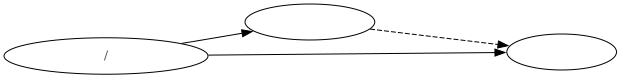

In [13]:
import graphviz as gr

g = gr.Digraph()
g.attr(rankdir="LR")
g.node("resources", "학교 재정/기반 여건")
g.node("tablet", "태블릿 도입")
g.node("score", "시험 성적")

g.edge("resources", "tablet")
g.edge("resources", "score")
g.edge("tablet", "score", style="dashed", label="알고 싶은 효과")

g


## 3) 그렇다면 언제 연관성이 인과관계가 될까?

앞서 살펴본 식을 다시 떠올려봅시다.

$E[Y|T=1] - E[Y|T=0] = \underbrace{E[Y_1 - Y_0|T=1]}_{ATT} + \underbrace{\{E[Y_0|T=1] - E[Y_0|T=0]\}}_{\text{Bias}}$

연관성이 인과관계가 되려면 편향 항이 0이 되어야 합니다. 즉, $E[Y_0|T=1] = E[Y_0|T=0]$이어야 합니다. 이를 말로 풀면 이렇습니다. "태블릿을 받은 학교가 태블릿을 받지 않았더라도, 받지 않은 학교와 평균적으로 비슷한 성적을 냈을 것이다." 두 집단이 태블릿 여부를 제외하면 애초에 비슷한 조건이었다는 뜻입니다.

이 조건이 충족되면 편향이 사라지고, 단순 평균 차이는 ATT와 같아집니다.

나아가 처치를 받은 집단과 받지 않은 집단이 처치에 유사하게 반응한다면, 즉 $E[Y_1 - Y_0|T=1] = E[Y_1 - Y_0|T=0]$이면 ATT는 ATC(Average Treatment Effect on the Control)와 같아지고, 결국 단순 평균 차이가 전체 평균인 ATE와 같아집니다.

$$E[Y|T=1] - E[Y|T=0] = ATT = ATC = ATE$$

그림으로 살펴보겠습니다. 현실의 관찰 데이터에서 단순히 두 집단의 평균을 비교하면 아래와 같습니다.

![img](./assets/anatomy1.png)

두 집단의 차이에는 두 가지 원인이 섞여 있습니다. 하나는 태블릿 자체의 효과이고, 다른 하나는 학교 재정처럼 처치와 무관하게 두 집단을 애초에 다르게 만드는 요인입니다. 이것이 편향입니다.

실제 처치 효과(ITE)는 동일한 실험대상에 대해 처치를 받은 결과와 받지 않은 결과를 동시에 비교해야만 구할 수 있습니다. 아래 왼쪽 그림처럼 반사실까지 관찰할 수 있어야 하죠.

![img](./assets/anatomy2.png)

오른쪽 그림은 편향을 시각화한 것입니다. 모든 실험대상이 처치를 받지 않은 상태($Y_0$만 존재)에서 두 집단을 비교해도, 처치 집단과 비교 집단 사이에 이미 차이가 존재합니다. 이것이 바로 편향이며, 실제 처치 효과를 가립니다.

반면 태블릿이 학교에 무작위로 배정된다면 어떨까요? 부유한 학교든 그렇지 않은 학교든 태블릿을 받을 확률이 같아집니다.

![img](./assets/anatomy3.png)

이 경우 두 집단의 차이는 온전히 처치 효과로만 설명됩니다. 편향이 사라집니다.

![img](./assets/anatomy4.png)

처치를 받지 않은 상태만 가정해도 두 집단 사이에 차이가 없습니다. 비교 가능한 집단이 만들어진 것입니다.

편향을 제거하고 두 집단을 비교 가능하게 만드는 것, 이것이 인과추론의 핵심 과제입니다. 그렇다면 현실에서 이를 가장 확실하게 달성하는 방법은 무엇일까요?

## 4) 편향을 가장 확실히 줄이는 방법: 무작위 실험(RCT)

사실 앞선 설명에서 이미 답이 나왔습니다. 바로 무작위 배정입니다. 처치를 무작위로 할당하면 잠재적 결과의 분포 전체가 처치 여부와 독립이 됩니다.

$$(Y_0, Y_1) \perp T$$

이 조건이 성립하면 앞서 살펴본 두 조건이 자동으로 충족됩니다.

- $E[Y_0|T=1] = E[Y_0|T=0]$: 편향이 사라지고,
- $E[Y_1|T=1] = E[Y_1|T=0]$: 처치에 대한 반응도 두 집단이 동등해집니다.

결과적으로 두 집단은 처치 여부를 제외한 모든 면에서 평균적으로 비슷해집니다. 즉, 처치 집단과 비교 집단이 비교 가능해지고, 단순 평균 차이가 곧 ATE가 됩니다.

$$E[Y\mid T=1] - E[Y\mid T=0] = ATT = ATC = ATE$$

이것이 무작위 대조 실험(RCT, Randomized Controlled Trial)이 인과효과 추정의 gold standard로 불리는 이유입니다.

### 4-1) 사례: 온라인 수업 실험

실제 데이터로 확인해볼게요. 지금까지는 태블릿 예시를 사용했지만, 여기서는 온라인 수업 방식이 학업 성취도에 미치는 효과를 분석한 실험 데이터를 활용합니다. 

대학교 수업을 대면, 온라인, 혼합의 세 가지 방식으로 무작위 배정한 실험으로, 어떤 수업 방식을 받을지는 학생의 특성과 무관하게 결정되었습니다. 
처치($T$)는 수업 방식이고, 결과 변수($Y$)는 기말 시험 점수입니다.

만약 무작위 배정 없이 단순 비교를 했다면 어떤 문제가 생길까요? 온라인 수업을 선택한 학생이 원래 자기주도 학습 능력이 뛰어난 집단일 수도 있고, 반대로 생계 부담이 커서 통학이 어려운 집단일 수도 있습니다. 이런 편향이 결과에 섞여들면 수업 방식의 순수한 효과를 알 수 없습니다. 무작위 배정은 이런 편향을 평균적으로 제거해줍니다.

In [34]:
import pandas as pd
import numpy as np

data = pd.read_csv("./data/online_classroom.csv")
print(data.shape)
data.head()

(323, 10)


,gender,asian,black,hawaiian,hispanic,unknown,white,format_ol,format_blended,falsexam
0,0,0.0,0.0,0.0,0.0,0.0,1.0,0,0.0,63.29997
1,1,0.0,0.0,0.0,0.0,0.0,1.0,0,0.0,79.96000
2,1,0.0,0.0,0.0,0.0,0.0,1.0,0,1.0,83.37000
3,1,0.0,0.0,0.0,0.0,0.0,1.0,0,1.0,90.01994
4,1,0.0,0.0,0.0,0.0,0.0,1.0,1,0.0,83.30000


In [35]:
(data
 .assign(class_format = np.select(
     [data["format_ol"].astype(bool), data["format_blended"].astype(bool)],
     ["online", "blended"],
     default="face_to_face"
 ))
 .groupby(["class_format"])
 .mean())

,gender,asian,black,hawaiian,hispanic,unknown,white,format_ol,format_blended,falsexam
class_format,,,,,,,,,,
blended,0.550459,0.217949,0.102564,0.025641,0.012821,0.012821,0.628205,0.0,1.0,77.093731
face_to_face,0.633333,0.202020,0.070707,0.000000,0.010101,0.000000,0.717172,0.0,0.0,78.547485
online,0.542553,0.228571,0.028571,0.014286,0.028571,0.000000,0.700000,1.0,0.0,73.635263


RCT에서 인과효과를 추정하는 방법은 간단합니다. 각 집단의 평균 점수를 계산하면 됩니다. 대면 수업 평균은 78.54점, 온라인 수업 평균은 73.63점으로, 추정 ATE는 약 -4.91점이네요. 온라인 수업이 학생들의 성적을 평균적으로 약 5점 낮춘다는 의미입니다.

이게 전부입니다. 온라인 수업을 듣는 학생이 저소득층인지, 원래 학습 능력이 달랐는지 걱정할 필요가 없습니다. 무작위 배정이 이런 편향을 설계 단계에서 이미 제거했기 때문입니다.

물론 무작위화가 실제로 잘 이루어졌는지는 검증해야 합니다. 성별, 인종, 기초 성적 등 변수가 집단 간에 균형을 이루는지 확인하는 것이 좋습니다. 이 데이터에서는 `gender`, `asian`, `hispanic`, `white` 변수가 집단 간에 유사하게 나타났지만, `black` 변수는 다소 차이를 보이네요. 소규모 데이터에서는 무작위 배정을 하더라도 이처럼 우연히 불균형이 생길 수 있으며, 표본이 클수록 이런 차이는 자연스럽게 줄어듭니다.

### 4-2) 현실의 한계와 배정 메커니즘

RCT는 간단하면서도 강력한 방법이지만, 현실에서 항상 가능한 것은 아닙니다. 비용이 너무 크거나, 윤리적으로 불가능하거나, 정책 단위로 통제가 어려운 경우가 많습니다. 임신 중 흡연이 신생아 체중에 미치는 영향을 알고 싶다고 해서 임산부에게 흡연을 무작위 배정할 수는 없습니다.

그렇더라도 인과 질문을 다룰 때는 항상 "이상적인 실험이라면 어떻게 설계할까?"를 먼저 떠올려야 합니다. 이 사고 실험이 관찰연구 설계의 기준점이 됩니다.

이럴 때 활용하는 것이 앞으로 다룰 준실험(Quasi-experiment) 방법론입니다. RCT처럼 $(Y_0, Y_1) \perp T$를 직접 확보할 수는 없지만, "어떤 공변량을 통제하면 처치가 사실상 무작위처럼 보이는가?"를 고민하며 두 집단을 최대한 비교 가능하게 만들려는 시도입니다.

이 가정이 타당할수록 인과 해석의 설득력이 올라갑니다. 앞으로 다룰 방법론들, Matching, DiD, Synthetic Control, IV, RDD는 모두 이 가정을 각자의 방식으로 만족시키려는 시도입니다. 방법은 달라도 목표는 하나입니다. 어떻게 하면 두 집단을 비교 가능하게 만들 수 있는가.

## 참고 자료

이 글은 Matheus Facure의 Python Causality Handbook을 참고하여 작성되었습니다.

- [01 - Introduction To Causality](https://matheusfacure.github.io/python-causality-handbook/01-Introduction-To-Causality.html)
- [02 - Randomised Experiments](https://matheusfacure.github.io/python-causality-handbook/02-Randomised-Experiments.html)
- [04 - Graphical Causal Models](https://matheusfacure.github.io/python-causality-handbook/04-Graphical-Causal-Models.html)